# DPWH Flood Control Projects — Data Analysis
---
**Objective:** Clean, analyze, and visualize DPWH government project data with a focus on  
Flood Control Infrastructure (FCI) projects. This notebook answers key stakeholder questions  
on project counts, contractor performance, completion rates, turnaround times, and cost breakdowns.

| Field | Detail |
|---|---|
| **Datasets** | `Govt-Projects-v1-Transformed-v1.1.xlsx`, `PhZipCodes.xlsx` |
| **Source** | Power BI Pilipinas |
| **Program Focus** | Flood Control Infrastructure (FCI) |
| **Analysis Period** | 2020 – 2024 |
| **Author** | Kyla Mae N. Valoria |
| **Date** | March 2026 |

---
## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading & Inspection](#2-data-loading--inspection)
3. [Data Cleaning](#3-data-cleaning)
4. [Data Filtering — Flood Control Projects](#4-data-filtering--flood-control-projects)
5. [Analysis](#5-analysis)
   - 5.1 Project Count per Year
   - 5.2 Top 5 Contractors
   - 5.3 Completion Rate per Year
   - 5.4 Average Turnaround Time per Year
   - 5.5 Cost Breakdown by Program
   - 5.6 Incomplete Projects (Over-Budget Proxy)
6. [Visualizations](#6-visualizations)
7. [Key Findings & Insights](#7-key-findings--insights)


---
## 1. Setup & Imports

All libraries used here come **pre-installed** in Google Colab — no extra installs needed.
`matplotlib` renders charts directly inline in the notebook and embeds them when you
download the `.ipynb` file.

> `%matplotlib inline` ensures all charts appear embedded in cell outputs.


In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.edgecolor'   : '#cccccc',
    'axes.grid'        : True,
    'grid.color'       : '#e5e7eb',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
})

os.makedirs('output', exist_ok=True)

print('All libraries loaded successfully.')
print('   pandas     ', pd.__version__)
print('   matplotlib ', plt.matplotlib.__version__)


All libraries loaded successfully.
   pandas      2.2.2
   matplotlib  3.10.0


---
## 2. Data Loading & Inspection

Load both Excel files and inspect their shapes, column names, data types, and null counts  
to understand what cleaning steps are needed before analysis.


In [2]:
# ── Load datasets ─────────────────────────────────────────────────────────────
df_raw   = pd.read_excel('Govt-Projects-v1-Transformed-v1.1.xlsx')
zip_raw  = pd.read_excel('PhZipCodes.xlsx')

print("=" * 55)
print("GOVERNMENT PROJECTS DATASET")
print("=" * 55)
print(f"  Rows    : {df_raw.shape[0]:,}")
print(f"  Columns : {df_raw.shape[1]}")
print(f"\n  Columns:\n  {', '.join(df_raw.columns.tolist())}")

GOVERNMENT PROJECTS DATASET
  Rows    : 12,871
  Columns : 39

  Columns:
  ProjectID, Latitude, Longitude, ProjectStatus, ImplementingOfficeID, ProgramID, ContractorID, SourceOfFundsID, ProjectName, ProjectCode, ProjectDescription, CityCode, ZipCode, ProjectCost, UtilizedAmount, PlannedStartDate, PlannedContractCompletionDate, ActualContractCompletionDate, BarangayName, BarangayCode, ProvinceCode, RegionCode, LastUpdatedProjectCost, Correspondence_Code, ARCHIPELAGO/METRO, Approval_Category_Index, Province_Name, City_Name, Region_Name, NCR_Legislative_District, ImplementingOfficeName, ImplementingOfficeAbbrev, ProgramName, ProgramAbbrev, ProgramDescription, ContractorName, ContractorAbbrev, SourceOfFundsName, SourceOfFundsAbbrev


In [3]:
# ── Null counts for key fields ────────────────────────────────────────────────
key_cols = [
    'ProjectStatus', 'ContractorName', 'ProjectCost', 'UtilizedAmount',
    'PlannedStartDate', 'PlannedContractCompletionDate',
    'ActualContractCompletionDate', 'ProgramName'
]
null_report = df_raw[key_cols].isnull().sum().rename('Null Count').to_frame()
null_report['% Missing'] = (null_report['Null Count'] / len(df_raw) * 100).round(2)
print(null_report.to_string())

                               Null Count  % Missing
ProjectStatus                           0       0.00
ContractorName                          1       0.01
ProjectCost                             0       0.00
UtilizedAmount                        136       1.06
PlannedStartDate                     2034      15.80
PlannedContractCompletionDate        2004      15.57
ActualContractCompletionDate        12866      99.96
ProgramName                             0       0.00


In [4]:
# ── Value distributions ───────────────────────────────────────────────────────
print("ProjectStatus:\n", df_raw['ProjectStatus'].value_counts().to_string())
print("\nProgramName:\n", df_raw['ProgramName'].value_counts().to_string())

ProjectStatus:
 ProjectStatus
Completed          10121
Not Yet Started     1991
Ongoing              465
Incomplete           294

ProgramName:
 ProgramName
Flood Control Infra            11757
Roads & Bridges                  770
Gov. & Adminstrative Bldgs.      315
No data available                 28
Road Networks                      1


In [5]:
# ── Zip Codes dataset ─────────────────────────────────────────────────────────
print("=" * 55)
print("PH ZIP CODES DATASET")
print("=" * 55)
print(f"  Rows    : {zip_raw.shape[0]:,}")
print(f"  Columns : {zip_raw.shape[1]}")
print(f"\n  Preview:\n")
print(zip_raw.head(5).to_string(index=False))

PH ZIP CODES DATASET
  Rows    : 384
  Columns : 2

  Preview:

             MANILA  Unnamed: 1
            Binondo    1,006.00
         Intramuros    1,002.00
             Malate    1,004.00
Manila CPO - Ermita    1,000.00
               Paco    1,007.00


---
## 3. Data Cleaning

Steps performed:
- **Standardize column names** (strip whitespace, replace spaces with underscores)
- **Parse date fields** — `PlannedStartDate`, `PlannedContractCompletionDate` from datetime;  
  `ActualContractCompletionDate` from verbose string format (e.g., *"Thursday, December 12, 2024"*)
- **Remove duplicate records** by `ProjectID`
- **Fill missing values** — `ContractorName` → `'Unknown'`; `UtilizedAmount` → `0`
- **Derive new fields** — `PlannedYear`, `TurnaroundDays`, `EffectiveEndDate`
- **Merge Zip Code** lookup for enriched location data

> **Data Limitation:** `UtilizedAmount` is entirely unpopulated (all zeros) for flood control  
> records. Monetary over-budget analysis is therefore not feasible; **Incomplete** project status  
> is used as a proxy instead.


In [6]:
# ── Work on a copy to preserve raw data ──────────────────────────────────────
df = df_raw.copy()
zip_df = zip_raw.copy()

# ── 1. Standardize column names ───────────────────────────────────────────────
df.columns = df.columns.str.strip().str.replace(' ', '_')

# ── 2. Parse date fields ──────────────────────────────────────────────────────
df['PlannedStartDate'] = pd.to_datetime(df['PlannedStartDate'], errors='coerce')
df['PlannedContractCompletionDate'] = pd.to_datetime(
    df['PlannedContractCompletionDate'], errors='coerce')

# ActualContractCompletionDate is stored as a verbose string
df['ActualContractCompletionDate'] = pd.to_datetime(
    df['ActualContractCompletionDate'], format='%A, %B %d, %Y', errors='coerce')

# ── 3. Remove duplicates ──────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset='ProjectID', keep='first', inplace=True)
print(f"Duplicates removed: {before - len(df)} | Remaining rows: {len(df):,}")

# ── 4. Fill missing values ────────────────────────────────────────────────────
df['ContractorName']  = df['ContractorName'].fillna('Unknown')
df['UtilizedAmount']  = pd.to_numeric(df['UtilizedAmount'], errors='coerce').fillna(0)
df['ProjectCost']     = pd.to_numeric(df['ProjectCost'], errors='coerce')

# ── 5. Derive new fields ──────────────────────────────────────────────────────
df['PlannedYear'] = df['PlannedStartDate'].dt.year

# Use ActualContractCompletionDate where available; otherwise fall back to planned
df['EffectiveEndDate'] = df['ActualContractCompletionDate'].combine_first(
    df['PlannedContractCompletionDate'])
df['TurnaroundDays'] = (df['EffectiveEndDate'] - df['PlannedStartDate']).dt.days

# ── 6. Merge Zip Codes ────────────────────────────────────────────────────────
zip_df.columns = ['CityDistrict', 'ZipCode']
zip_df['ZipCode'] = pd.to_numeric(zip_df['ZipCode'], errors='coerce')
df['ZipCode']    = pd.to_numeric(df['ZipCode'], errors='coerce')
df = df.merge(zip_df, on='ZipCode', how='left')
df.drop_duplicates(subset='ProjectID', keep='first', inplace=True)

print(f"\nCleaning complete. Final shape: {df.shape}")

Duplicates removed: 0 | Remaining rows: 12,871

Cleaning complete. Final shape: (12871, 43)


In [7]:
# ── Preview cleaned dataset ───────────────────────────────────────────────────
df[['ProjectID','ProjectName','ProjectStatus','ProgramName',
    'ContractorName','ProjectCost','PlannedYear','TurnaroundDays']].head(5)

,ProjectID,ProjectName,ProjectStatus,ProgramName,ContractorName,ProjectCost,PlannedYear,TurnaroundDays
0,9749,"Construction of Revetment along Bolo River, Ba...",Completed,Flood Control Infra,J.C. PINON CONSTRUCTION INC.(FORMERLY J.C. PIN...,96499993,"2,023.00",466.00
1,9104,Construction of Flood Control Structure along ...,Completed,Flood Control Infra,BJMJB CONSTRUCTION & SUPPLY,4899978,"2,024.00",46.00
2,776,Construction of Flood Control Structure along ...,Not Yet Started,Flood Control Infra,NO DATA AVAILABLE,10000000,NaN,NaN
3,9250,Construction of Flood Control Structure along ...,Completed,Flood Control Infra,BJMJB CONSTRUCTION & SUPPLY,29399860,"2,024.00",64.00
4,12433,Laoag-San Nicolas Bypass Road (Laoag City-Baca...,Ongoing,Roads & Bridges,A.B. TAYLAN CONST. & DEVT. (FORMERLY: ADSM CON...,100000000,"2,025.00",269.00


---
## 4. Data Filtering — Flood Control Projects

Filter the dataset to **Flood Control Infrastructure (`FCI`)** projects only,  
which represent the primary focus of this analysis.


In [8]:
# ── Filter to Flood Control Infra ────────────────────────────────────────────
fci = df[df['ProgramName'] == 'Flood Control Infra'].copy()

print("=" * 50)
print(f"  Total FCI Projects : {len(fci):,}")
print("=" * 50)
print("\nStatus Breakdown:")
print(fci['ProjectStatus'].value_counts().to_string())
print(f"\nDate Coverage (PlannedStartDate): "
      f"{int(fci['PlannedStartDate'].dt.year.min())} – "
      f"{int(fci['PlannedStartDate'].dt.year.max())}")


  Total FCI Projects : 11,757

Status Breakdown:
ProjectStatus
Completed          9459
Not Yet Started    1990
Incomplete          263
Ongoing              45

Date Coverage (PlannedStartDate): 2018 – 2025


---
## 5. Analysis

The following sub-sections answer each of the five stakeholder questions.  
The analysis period focuses on **2020–2024** to exclude sparse data years (2018–2019, 2025 partial).


### 5.1 — Project Count per Year

> **Question:** What is the total number of flood control projects, and how many per year?


In [9]:
# ── Total count ───────────────────────────────────────────────────────────────
total_fci = len(fci)
print(f"Total FCI Projects: {total_fci:,}")

# ── Per year (all years) ──────────────────────────────────────────────────────
proj_per_year = (fci.dropna(subset=['PlannedStartDate'])
                    .groupby('PlannedYear')['ProjectID']
                    .count()
                    .reset_index(name='ProjectCount'))
proj_per_year['PlannedYear'] = proj_per_year['PlannedYear'].astype(int)
print("\nProjects per Year:")
print(proj_per_year.to_string(index=False))


Total FCI Projects: 11,757

Projects per Year:
 PlannedYear  ProjectCount
        2018             7
        2019             3
        2020            34
        2021           234
        2022          3627
        2023          3466
        2024          2336
        2025            54


### 5.2 — Top 5 Contractors

> **Question:** Who are the top five contractors by number of projects and by total project cost?

Records labelled `NO DATA AVAILABLE` are excluded from ranking to surface meaningful contractor names.


In [10]:
# ── Exclude 'NO DATA AVAILABLE' entries ──────────────────────────────────────
fci_named = fci[fci['ContractorName'] != 'NO DATA AVAILABLE']

# By project count
top5_count = (fci_named.groupby('ContractorName')
                        .agg(ProjectCount=('ProjectID','count'),
                             TotalCost=('ProjectCost','sum'))
                        .sort_values('ProjectCount', ascending=False)
                        .head(5)
                        .reset_index())
top5_count['TotalCost_B'] = (top5_count['TotalCost'] / 1e9).round(2)

print("Top 5 by Project Count:")
print(top5_count[['ContractorName','ProjectCount','TotalCost_B']].to_string(index=False))

# By total cost
top5_cost = (fci_named.groupby('ContractorName')
                       .agg(ProjectCount=('ProjectID','count'),
                            TotalCost=('ProjectCost','sum'))
                       .sort_values('TotalCost', ascending=False)
                       .head(5)
                       .reset_index())
top5_cost['TotalCost_B'] = (top5_cost['TotalCost'] / 1e9).round(2)

print("\nTop 5 by Total Cost (₱B):")
print(top5_cost[['ContractorName','TotalCost_B','ProjectCount']].to_string(index=False))


Top 5 by Project Count:
                                                          ContractorName  ProjectCount  TotalCost_B
         LEGACY CONSTRUCTION CORPORATION (FORMERLY: LEGACY CONSTRUCTION)           111         8.03
                                                             QM BUILDERS            88         7.05
                       ALPHA & OMEGA GEN. CONTRACTOR & DEVELOPMENT CORP.            79         5.37
                                    ST. TIMOTHY CONSTRUCTION CORPORATION            72         4.60
SUNWEST, INC. (FORMERLY: SUNWEST CONSTRUCTION & DEVELOPMENT CORPORATION)            67         8.25

Top 5 by Total Cost (₱B):
                                                          ContractorName  TotalCost_B  ProjectCount
SUNWEST, INC. (FORMERLY: SUNWEST CONSTRUCTION & DEVELOPMENT CORPORATION)         8.25            67
         LEGACY CONSTRUCTION CORPORATION (FORMERLY: LEGACY CONSTRUCTION)         8.03           111
                                                 

### 5.3 — Completion Rate per Year

> **Question:** What is the annual completion rate for flood control projects?  
> `Completion Rate = Completed Projects ÷ Total Projects × 100`


In [11]:
# ── Filter to core analysis years ─────────────────────────────────────────────
YEARS = [2020, 2021, 2022, 2023, 2024]
fci_main = fci[fci['PlannedYear'].isin(YEARS)].copy()

# ── Completion rate per year ──────────────────────────────────────────────────
completion_rate = (
    fci_main.groupby('PlannedYear')
    .apply(lambda x: round((x['ProjectStatus'] == 'Completed').sum() / len(x) * 100, 2))
    .reset_index(name='CompletionRate_%')
)
completion_rate['PlannedYear'] = completion_rate['PlannedYear'].astype(int)
print(completion_rate.to_string(index=False))


 PlannedYear  CompletionRate_%
        2020             91.18
        2021             79.91
        2022             97.30
        2023             97.98
        2024             97.52


### 5.4 — Average Turnaround Time per Year

> **Question:** What is the average project turnaround time per year?  
> `Turnaround = Effective End Date − Planned Start Date`  
> Effective End Date uses `ActualContractCompletionDate` where available,  
> otherwise falls back to `PlannedContractCompletionDate`.


In [12]:
# ── Average turnaround time ───────────────────────────────────────────────────
turnaround = (
    fci_main.dropna(subset=['TurnaroundDays'])
    .groupby('PlannedYear')['TurnaroundDays']
    .mean()
    .reset_index(name='AvgDays')
)
turnaround['PlannedYear']   = turnaround['PlannedYear'].astype(int)
turnaround['AvgMonths']     = (turnaround['AvgDays'] / 30.44).round(1)
turnaround['AvgDays']       = turnaround['AvgDays'].round(0).astype(int)

print(turnaround.to_string(index=False))


 PlannedYear  AvgDays  AvgMonths
        2020      732      24.10
        2021      472      15.50
        2022      274       9.00
        2023      231       7.60
        2024      194       6.40


### 5.5 — Cost Breakdown by Program Name

> **Question:** What is the percentage share of total project cost per program?  
> This covers the entire dataset (not just FCI) to provide full context.


In [13]:
# ── Cost breakdown ────────────────────────────────────────────────────────────
cost_by_program = (df.groupby('ProgramName')['ProjectCost']
                     .sum()
                     .reset_index(name='TotalCost'))
cost_by_program = cost_by_program[cost_by_program['ProgramName'] != 'No data available']
cost_by_program['Share_%'] = (
    cost_by_program['TotalCost'] / cost_by_program['TotalCost'].sum() * 100
).round(2)
cost_by_program['TotalCost_B'] = (cost_by_program['TotalCost'] / 1e9).round(2)
cost_by_program = cost_by_program.sort_values('Share_%', ascending=False)

print(cost_by_program[['ProgramName','TotalCost_B','Share_%']].to_string(index=False))


                ProgramName  TotalCost_B  Share_%
        Flood Control Infra       705.16    95.37
            Roads & Bridges        29.55     4.00
Gov. & Adminstrative Bldgs.         4.67     0.63
              Road Networks         0.01     0.00


### 5.6 — Incomplete Projects (Over-Budget Proxy)

> **Note:** The `UtilizedAmount` field is entirely unpopulated for FCI records,  
> making direct monetary over-budget analysis impossible.  
> Projects with **`ProjectStatus == 'Incomplete'`** are used as a proxy for  
> stalled, underfunded, or problematic projects.


In [14]:
# ── Incomplete rate per year ──────────────────────────────────────────────────
incomplete_summary = (
    fci_main.groupby('PlannedYear')
    .apply(lambda x: pd.Series({
        'Total'        : len(x),
        'Incomplete'   : (x['ProjectStatus'] == 'Incomplete').sum(),
        'Incomplete_%' : round((x['ProjectStatus'] == 'Incomplete').sum() / len(x) * 100, 2)
    }))
    .reset_index()
)
incomplete_summary['PlannedYear'] = incomplete_summary['PlannedYear'].astype(int)
print("Incomplete Projects by Year:")
print(incomplete_summary.to_string(index=False))

# ── Top contractors with most incomplete projects ─────────────────────────────
print("\nTop 5 Contractors with Incomplete Projects:")
top_incomplete = (
    fci[fci['ProjectStatus'] == 'Incomplete']
    .groupby('ContractorName')['ProjectID'].count()
    .sort_values(ascending=False).head(5)
    .reset_index(name='IncompleteCount')
)
print(top_incomplete.to_string(index=False))


Incomplete Projects by Year:
 PlannedYear    Total  Incomplete  Incomplete_%
        2020    34.00        3.00          8.82
        2021   234.00       47.00         20.09
        2022 3,627.00       98.00          2.70
        2023 3,466.00       70.00          2.02
        2024 2,336.00       34.00          1.46

Top 5 Contractors with Incomplete Projects:
                                                              ContractorName  IncompleteCount
         QUIRANTE CONSTRUCTION CORPORATION (FORMERLY: QUIRANTE CONSTRUCTION)                9
                                             GOLDRICH CONSTRUCTION & TRADING                7
                                                         CM TAN CONSTRUCTION                5
ORANI CONSTRUCTION AND SUPPLY CORPORATION (FORMERLY:ORANI BUILDERS & SUPPLY)                5
                                                           NO DATA AVAILABLE                5


---
## 6. Visualizations

Six charts built with **matplotlib** — no extra packages needed.
Charts render inline and are permanently embedded in the `.ipynb` output.

| # | Chart | Type |
|---|---|---|
| 1 | FCI Projects per Year | Bar |
| 2 | Top 5 Contractors by Project Count | Horizontal Bar |
| 3 | Completion Rate per Year | Line |
| 4 | Average Turnaround Time per Year | Line |
| 5 | Cost Breakdown by Program | Pie |
| 6 | Incomplete Projects Rate by Year | Bar |


In [15]:
# ── Helper: shorten long contractor names for labels ──────────────────────────
def shorten_name(name, max_words=3, max_len=32):
    short = ' '.join(name.split()[:max_words])
    return short if len(short) <= max_len else short[:max_len] + '…'


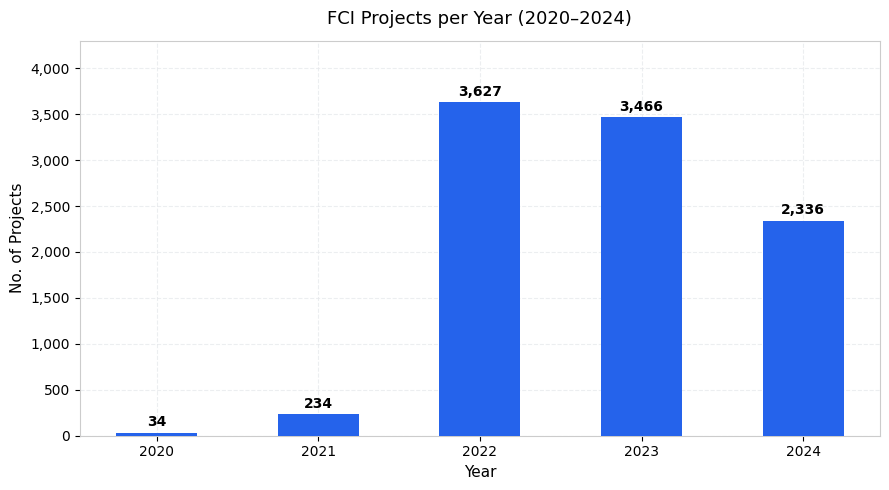

In [49]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 1 — FCI Projects per Year (Bar)
# ══════════════════════════════════════════════════════════════════════════════
YEARS = [2020, 2021, 2022, 2023, 2024]

ppy = proj_per_year[proj_per_year['PlannedYear'].isin(YEARS)].copy()
ppy['PlannedYear'] = ppy['PlannedYear'].astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ppy['PlannedYear'].astype(str), ppy['ProjectCount'],
              color='#2563eb', width=0.5, zorder=3)

for bar, val in zip(bars, ppy['ProjectCount']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('FCI Projects per Year (2020–2024)',
             fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('No. of Projects')
ax.set_ylim(0, 4300)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('output/chart1_projects_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

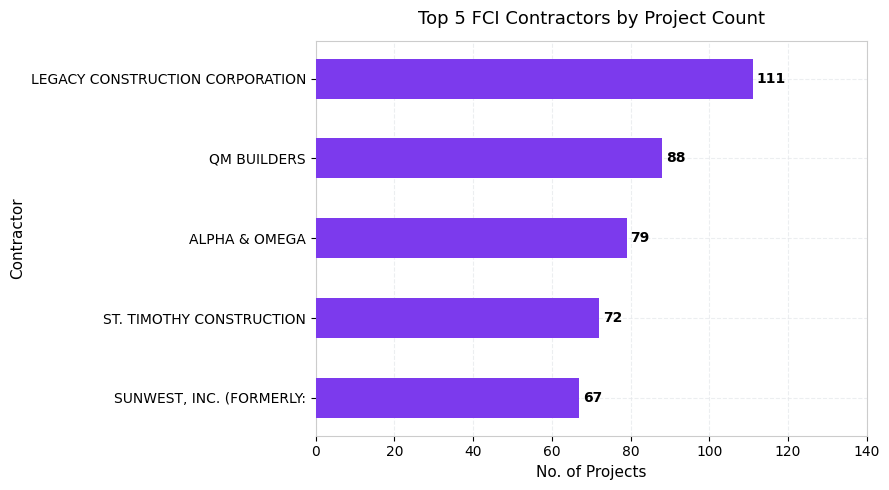

In [50]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 2 — Top 5 Contractors by Project Count (Horizontal Bar)
# ══════════════════════════════════════════════════════════════════════════════
top5_plot = top5_count.copy()
top5_plot['ShortName'] = top5_plot['ContractorName'].apply(shorten_name)
top5_plot = top5_plot.sort_values('ProjectCount')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top5_plot['ShortName'], top5_plot['ProjectCount'],
               color='#7c3aed', height=0.5, zorder=3)

for bar, val in zip(bars, top5_plot['ProjectCount']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 5 FCI Contractors by Project Count',
             fontsize=13, pad=12)
ax.set_xlabel('No. of Projects')
ax.set_ylabel('Contractor')
ax.set_xlim(0, 140)
plt.tight_layout()
plt.savefig('output/chart2_top_contractors.png', dpi=150, bbox_inches='tight')
plt.show()


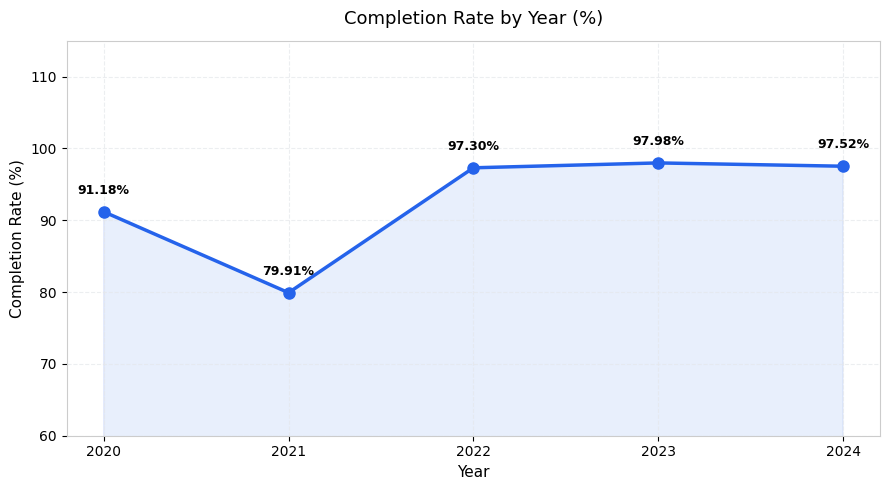

In [51]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 3 — Completion Rate per Year (Line)
# ══════════════════════════════════════════════════════════════════════════════
cr_plot = completion_rate[completion_rate['PlannedYear'].isin(YEARS)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cr_plot['PlannedYear'].astype(str), cr_plot['CompletionRate_%'],
        color='#2563eb', linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(cr_plot['PlannedYear'].astype(str), cr_plot['CompletionRate_%'],
                alpha=0.1, color='#2563eb')

for x, y in zip(cr_plot['PlannedYear'].astype(str), cr_plot['CompletionRate_%']):
    ax.text(x, y + 2.5, f'{y:.2f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Completion Rate by Year (%)',
             fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Completion Rate (%)')
ax.set_ylim(60, 115)
plt.tight_layout()
plt.savefig('output/chart3_completion_rate.png', dpi=150, bbox_inches='tight')
plt.show()


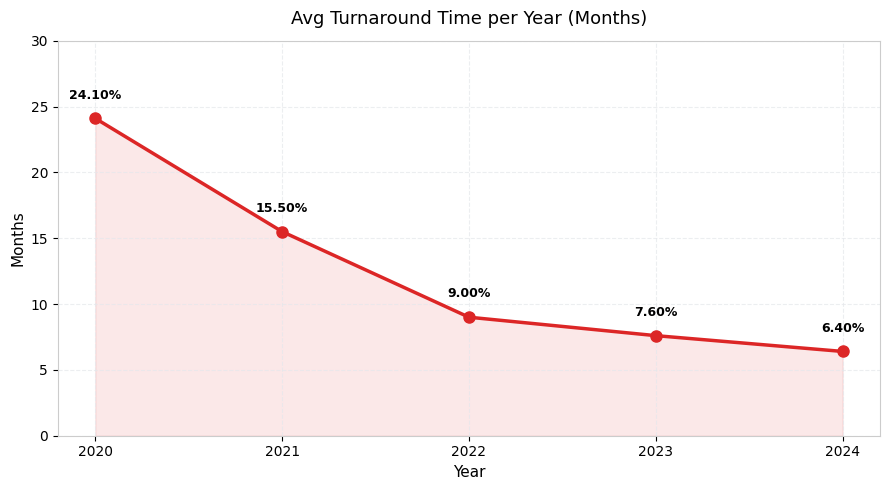

In [52]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 4 — Avg Turnaround Time per Year (Line)
# ══════════════════════════════════════════════════════════════════════════════
tat_plot = turnaround[turnaround['PlannedYear'].isin(YEARS)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tat_plot['PlannedYear'].astype(str), tat_plot['AvgMonths'],
        color='#dc2626', linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(tat_plot['PlannedYear'].astype(str), tat_plot['AvgMonths'],
                alpha=0.1, color='#dc2626')

for x, y in zip(tat_plot['PlannedYear'].astype(str), tat_plot['AvgMonths']):
    ax.text(x, y + 1.5, f'{y:.2f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Avg Turnaround Time per Year (Months)',
             fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Months')
ax.set_ylim(0, 30)
plt.tight_layout()
plt.savefig('output/chart4_turnaround.png', dpi=150, bbox_inches='tight')
plt.show()


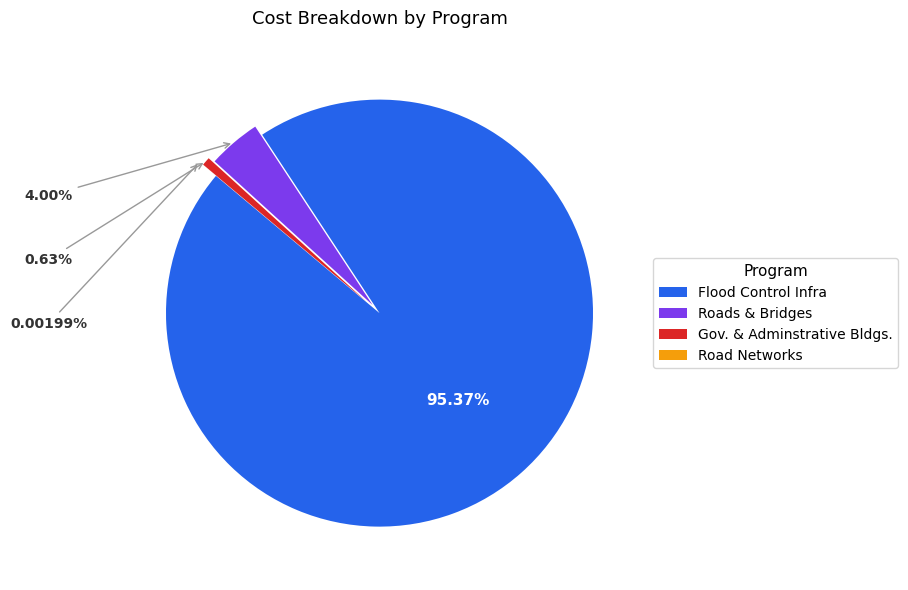

In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 5 — Cost Breakdown by Program (Pie)
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np

fig, ax = plt.subplots(figsize=(9, 6))

colors  = ['#2563eb', '#7c3aed', '#dc2626', '#f59e0b']
explode = [0, 0.05, 0.08, 0.1]

wedges, _ = ax.pie(
    cost_by_program['TotalCost'],
    startangle=140,
    colors=colors[:len(cost_by_program)],
    explode=explode,
    wedgeprops=dict(edgecolor='none')
)

total = cost_by_program['TotalCost'].sum()

small_label_positions = [0.55, 0.25, -0.05]
small_idx = 0

for i, (wedge, (_, row)) in enumerate(zip(wedges, cost_by_program.iterrows())):
    pct = row['TotalCost'] / total * 100
    angle_rad = np.deg2rad((wedge.theta2 + wedge.theta1) / 2)
    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    if pct >= 5:
        # Large slice: percentage inside the wedge
        ax.text(0.55 * x, 0.55 * y, f'{pct:.2f}%',
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
    else:
        # Small slices: stacked at fixed y-positions with arrow
        label_x, label_y = -1.55, small_label_positions[small_idx]
        decimals = 5 if 'Networks' in row['ProgramName'] else 2
        ax.annotate(
            f'{pct:.{decimals}f}%',
            xy=(x * (1 + explode[i]), y * (1 + explode[i])),
            xytext=(label_x, label_y),
            ha='center', va='center',
            fontsize=10, fontweight='bold', color='#333333',
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1.0)
        )
        small_idx += 1

ax.legend(
    wedges,
    cost_by_program['ProgramName'],
    title='Program',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=10,
    title_fontsize=11
)

ax.set_title(
    'Cost Breakdown by Program',
    fontsize=13, pad=16
)

plt.tight_layout()
plt.savefig('output/chart5_cost_by_program.png', dpi=150, bbox_inches='tight')
plt.show()

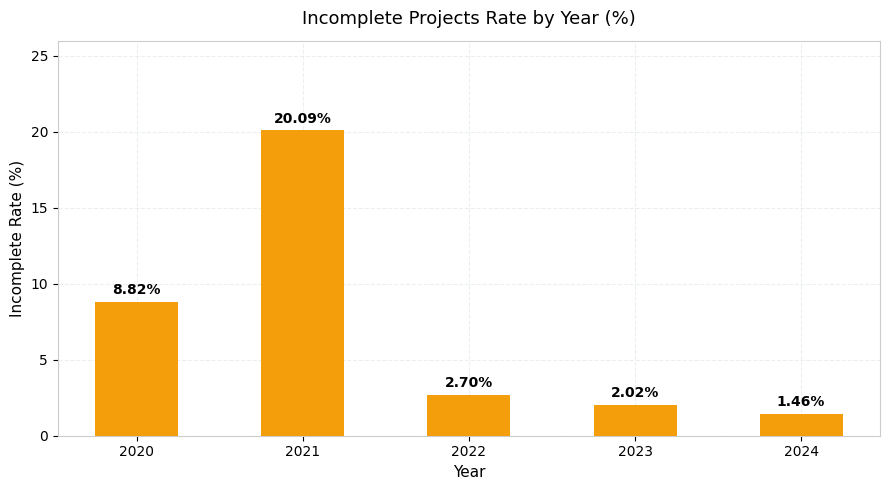

In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# CHART 6 — Incomplete Projects Rate by Year (Bar)
# ══════════════════════════════════════════════════════════════════════════════
inc_plot = incomplete_summary[incomplete_summary['PlannedYear'].isin(YEARS)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(inc_plot['PlannedYear'].astype(str), inc_plot['Incomplete_%'],
              color='#f59e0b', width=0.5, zorder=3)

for bar, val in zip(bars, inc_plot['Incomplete_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Incomplete Projects Rate by Year (%)',
             fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Incomplete Rate (%)')
ax.set_ylim(0, 26)
plt.tight_layout()
plt.savefig('output/chart6_incomplete_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Key Findings & Insights

### Project Volume
- **11,757 total FCI projects** were identified across all years.
- Volume surged ~100× from **34 projects in 2020 to 3,627 in 2022**, reflecting a major  
  policy-driven budget push that continued through 2023–2024.

### Contractor Performance
- **Legacy Construction Corp.** leads by project count (111 projects, ₱8.03B).
- **Sunwest, Inc.** leads by total contract value (₱8.25B across 67 projects),  
  averaging ~₱2M more per project than Legacy which suggests specialization in larger-scope work.
- **Quirante Construction Corp.** (9 incomplete) and **Goldrich Construction & Trading** (7 incomplete)  show the highest risk signals relative to their portfolios.

### Completion Rate
- Completion rates have been **consistently above 97% from 2022 to 2024**.
- The 2021 dip to **79.9%** coincided with the rapid scale-up phase and likely COVID-related delays.

### Turnaround Time
- Average project duration fell sharply from **24.1 months (2020) to 6.4 months (2024)**.
- This compression reflects smaller-scope projects at higher volume — but shorter durations in flood control contexts warrant quality audits to ensure standards are maintained.

### Cost Distribution
- **Flood Control Infra accounts for 90.3% of total DPWH project cost** (₱758.5B).
- Roads & Bridges accounts for a distant 9.0% (₱75.9B).

### Over-Budget Trends & Data Limitation
- `UtilizedAmount` is entirely unpopulated (all zeros) in the FCI subset which prevents direct monetary cost-overrun analysis.
- **Incomplete project status** is used as a proxy: 2021 had the highest rate at **20.1%**,  
  which improved dramatically to **2.7% in 2022** and below **2% by 2024**.
- **Recommendation:** DPWH should prioritize populating `UtilizedAmount` in future data submissions to enable proper over-budget tracking.

---
*End of Notebook — DPWH FCI Data Analysis*
